<a href="https://colab.research.google.com/github/chirontan/FEM/blob/main/Q_5_(b).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Solution to Q.5(b)**

In [1]:
import numpy as np


# =========================================================
# QUESTION 5(b)
# One-dimensional finite element program
# =========================================================

def solve_fem(Ne):

    # -----------------------------------------------------
    # Problem data
    # -----------------------------------------------------

    L = 1.0
    EA = 1.0
    b = 1.0

    # -----------------------------------------------------
    # Number of nodes
    # -----------------------------------------------------

    nnode = Ne + 1

    # -----------------------------------------------------
    # Uniform mesh
    # -----------------------------------------------------

    x = np.linspace(0.0, L, nnode)

    # -----------------------------------------------------
    # Global matrices
    # -----------------------------------------------------

    K = np.zeros((nnode, nnode))
    F = np.zeros(nnode)

    # -----------------------------------------------------
    # Element-by-element assembly
    # -----------------------------------------------------

    for e in range(Ne):

        # Element nodes
        n1 = e
        n2 = e + 1

        # Element length
        le = x[n2] - x[n1]

        # Element stiffness matrix
        ke = (EA / le) * np.array([
            [1.0, -1.0],
            [-1.0, 1.0]
        ])

        # Consistent element load vector
        fe = (b * le / 2.0) * np.array([
            1.0,
            1.0
        ])

        # Global assembly
        nodes = [n1, n2]

        for a in range(2):

            A = nodes[a]

            F[A] += fe[a]

            for bb in range(2):

                B = nodes[bb]

                K[A, B] += ke[a, bb]

    # -----------------------------------------------------
    # Apply essential boundary condition
    #
    # u(0) = 0
    # -----------------------------------------------------

    free = np.arange(1, nnode)

    Kff = K[np.ix_(free, free)]
    Ff = F[free]

    # -----------------------------------------------------
    # Solve reduced system
    # -----------------------------------------------------

    Uf = np.linalg.solve(Kff, Ff)

    # -----------------------------------------------------
    # Complete displacement vector
    # -----------------------------------------------------

    U = np.zeros(nnode)

    U[free] = Uf

    return x, K, F, U


# =========================================================
# Test for Ne = 2
# =========================================================

x, K, F, U = solve_fem(2)

print("Nodal coordinates:")
print(x)

print("\nGlobal stiffness matrix K:")
print(K)

print("\nGlobal load vector F:")
print(F)

print("\nNodal displacement vector U:")
print(U)

Nodal coordinates:
[0.  0.5 1. ]

Global stiffness matrix K:
[[ 2. -2.  0.]
 [-2.  4. -2.]
 [ 0. -2.  2.]]

Global load vector F:
[0.25 0.5  0.25]

Nodal displacement vector U:
[0.    0.375 0.5  ]


# **Solution to Q.5.(c)**


----------------------------------
Number of elements = 2
----------------------------------
Nodal coordinates:
[0.  0.5 1. ]

Nodal displacement vector:
[0.    0.375 0.5  ]

----------------------------------
Number of elements = 4
----------------------------------
Nodal coordinates:
[0.   0.25 0.5  0.75 1.  ]

Nodal displacement vector:
[0.      0.21875 0.375   0.46875 0.5    ]

----------------------------------
Number of elements = 8
----------------------------------
Nodal coordinates:
[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]

Nodal displacement vector:
[0.        0.1171875 0.21875   0.3046875 0.375     0.4296875 0.46875
 0.4921875 0.5      ]

----------------------------------
Number of elements = 16
----------------------------------
Nodal coordinates:
[0.     0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625
 0.625  0.6875 0.75   0.8125 0.875  0.9375 1.    ]

Nodal displacement vector:
[0.         0.06054688 0.1171875  0.16992188 0.21875    0.26367

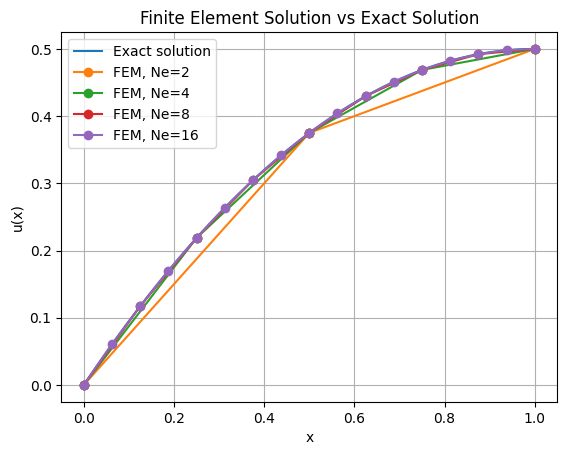

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# FEM solver
# =========================================================

def solve_fem(Ne):

    L = 1.0
    EA = 1.0
    b = 1.0

    nnode = Ne + 1

    x = np.linspace(0.0, L, nnode)

    K = np.zeros((nnode, nnode))
    F = np.zeros(nnode)

    # -----------------------------------------------------
    # Element assembly
    # -----------------------------------------------------

    for e in range(Ne):

        n1 = e
        n2 = e + 1

        le = x[n2] - x[n1]

        ke = (EA / le) * np.array([
            [1.0, -1.0],
            [-1.0, 1.0]
        ])

        fe = (b * le / 2.0) * np.array([
            1.0,
            1.0
        ])

        nodes = [n1, n2]

        for a in range(2):

            A = nodes[a]

            F[A] += fe[a]

            for bb in range(2):

                B = nodes[bb]

                K[A, B] += ke[a, bb]

    # -----------------------------------------------------
    # Boundary condition u(0) = 0
    # -----------------------------------------------------

    free = np.arange(1, nnode)

    Kff = K[np.ix_(free, free)]
    Ff = F[free]

    Uf = np.linalg.solve(Kff, Ff)

    U = np.zeros(nnode)

    U[free] = Uf

    return x, K, F, U


# =========================================================
# Question 5(c)
# =========================================================

for Ne in [2, 4, 8, 16]:

    x, K, F, U = solve_fem(Ne)

    print("\n----------------------------------")
    print("Number of elements =", Ne)
    print("----------------------------------")

    print("Nodal coordinates:")
    print(x)

    print("\nNodal displacement vector:")
    print(U)


# =========================================================
# Plot FEM and exact solution
# =========================================================

xx = np.linspace(0.0, 1.0, 500)

uexact = xx - xx**2 / 2.0

plt.figure()

# Exact solution
plt.plot(
    xx,
    uexact,
    label="Exact solution"
)

# FEM solutions
for Ne in [2, 4, 8, 16]:

    x, K, F, U = solve_fem(Ne)

    plt.plot(
        x,
        U,
        "o-",
        label=f"FEM, Ne={Ne}"
    )

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Finite Element Solution vs Exact Solution")

plt.legend()
plt.grid(True)

plt.show()

# **Solution to Q.5(d)**


Question 5(d): L2 Error
Ne        h              L2 error
2       0.50000000     2.2821773229e-02
4       0.25000000     5.7054433073e-03
8       0.12500000     1.4263608268e-03
16      0.06250000     3.5659020671e-04

Observed convergence rates
Between Ne=2 and Ne=4: p = 2.00000000
Between Ne=4 and Ne=8: p = 2.00000000
Between Ne=8 and Ne=16: p = 2.00000000


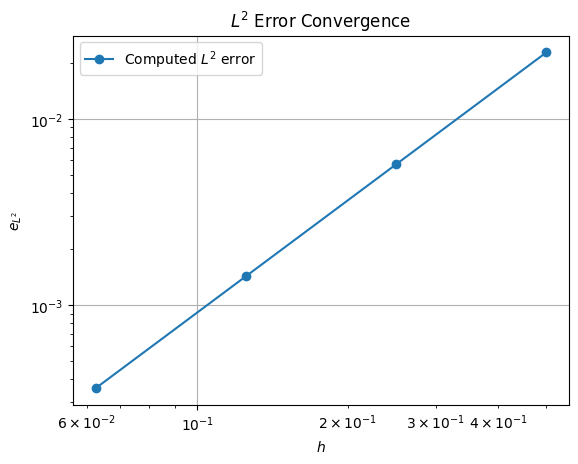

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# FEM solver
# =========================================================

def solve_fem(Ne):

    L = 1.0
    EA = 1.0
    b = 1.0

    nnode = Ne + 1

    x = np.linspace(0.0, L, nnode)

    K = np.zeros((nnode, nnode))
    F = np.zeros(nnode)

    for e in range(Ne):

        n1 = e
        n2 = e + 1

        le = x[n2] - x[n1]

        ke = (EA / le) * np.array([
            [1.0, -1.0],
            [-1.0, 1.0]
        ])

        fe = (b * le / 2.0) * np.array([
            1.0,
            1.0
        ])

        nodes = [n1, n2]

        for a in range(2):

            A = nodes[a]

            F[A] += fe[a]

            for bb in range(2):

                B = nodes[bb]

                K[A, B] += ke[a, bb]

    # Essential boundary condition
    free = np.arange(1, nnode)

    Kff = K[np.ix_(free, free)]
    Ff = F[free]

    Uf = np.linalg.solve(Kff, Ff)

    U = np.zeros(nnode)

    U[free] = Uf

    return x, U


# =========================================================
# Exact solution
# =========================================================

def u_exact(x):

    return x - x**2 / 2.0


# =========================================================
# Question 5(d)
# Continuous L2 error using 3-point Gauss quadrature
# =========================================================

def L2_error(Ne):

    x, U = solve_fem(Ne)

    # 3-point Gauss quadrature
    xi = np.array([
        -np.sqrt(3.0 / 5.0),
        0.0,
        np.sqrt(3.0 / 5.0)
    ])

    w = np.array([
        5.0 / 9.0,
        8.0 / 9.0,
        5.0 / 9.0
    ])

    error_squared = 0.0

    # -----------------------------------------------------
    # Element loop
    # -----------------------------------------------------

    for e in range(Ne):

        x1 = x[e]
        x2 = x[e + 1]

        u1 = U[e]
        u2 = U[e + 1]

        le = x2 - x1

        # -------------------------------------------------
        # Gauss point loop
        # -------------------------------------------------

        for q in range(3):

            # Map xi -> x
            xq = (
                (x1 + x2) / 2.0
                + (le / 2.0) * xi[q]
            )

            # Shape functions
            N1 = (1.0 - xi[q]) / 2.0
            N2 = (1.0 + xi[q]) / 2.0

            # FEM displacement
            uh = N1*u1 + N2*u2

            # Exact displacement
            ue = u_exact(xq)

            # Jacobian of transformation
            J = le / 2.0

            error_squared += (
                w[q]
                * (ue - uh)**2
                * J
            )

    return np.sqrt(error_squared)


# =========================================================
# Calculate errors
# =========================================================

Ne_values = [2, 4, 8, 16]

errors = []
h_values = []

print("\n==========================================")
print("Question 5(d): L2 Error")
print("==========================================")

print(
    "Ne        h              L2 error"
)

for Ne in Ne_values:

    h = 1.0 / Ne

    error = L2_error(Ne)

    h_values.append(h)
    errors.append(error)

    print(
        f"{Ne:<8d}"
        f"{h:<15.8f}"
        f"{error:.10e}"
    )


# =========================================================
# Convergence rates
# =========================================================

print("\nObserved convergence rates")

for i in range(len(Ne_values) - 1):

    p = np.log(errors[i] / errors[i+1]) / np.log(
        h_values[i] / h_values[i+1]
    )

    print(
        f"Between Ne={Ne_values[i]} "
        f"and Ne={Ne_values[i+1]}: p = {p:.8f}"
    )


# =========================================================
# Log-log convergence plot
# =========================================================

plt.figure()

plt.loglog(
    h_values,
    errors,
    "o-",
    label="Computed $L^2$ error"
)

plt.xlabel("$h$")
plt.ylabel("$e_{L^2}$")
plt.title("$L^2$ Error Convergence")

plt.grid(True)
plt.legend()

plt.show()

The continuous L^2 error decreases systematically as the mesh is refined. The observed convergence rate is approximately p=2, indicating e_{L^2} is proportional to  h^2. This is the expected L^2-norm convergence rate for a sufficiently smooth solution approximated using two node linear finite elements.